# 03 Bottleneck Analysis

**Goal:** Identify which operational factors cause elevated ED wait times so hospitals can target staffing and resource allocation.

All statistics are **PATWT-weighted** to represent national ED visit patterns.

Prerequisite: run `01_data_prep.ipynb` first.

**Sections:**
1. Weighted group comparisons — raw impact of each operational factor
2. Weighted HGB model + SHAP — isolate each factor's contribution controlling for other variables
3. Bottleneck ranking — which factors matter most nationally
4. Regional breakdown — where each bottleneck is worst

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', context='talk')
DATA = Path('../data')

df = pd.read_csv(DATA / 'model_B_retrospective_dataset.csv')
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'Columns: {list(df.columns)}')

# Force numeric
for c in df.columns:
    if c != 'ARRTIME':
        df[c] = pd.to_numeric(df[c], errors='coerce')

REGION_LABELS = {1: 'Northeast', 2: 'Midwest', 3: 'South', 4: 'West'}
IMMEDR_LABELS = {1: 'Immediate', 2: 'Emergent', 3: 'Urgent', 4: 'Semi-urgent', 5: 'Non-urgent'}

def wmean(values, weights):
    mask = values.notna() & weights.notna()
    if mask.sum() == 0:
        return np.nan
    return np.average(values[mask], weights=weights[mask])

OVERALL_WMEAN = wmean(df['WAITTIME'], df['PATWT'])
print(f'\nOverall PATWT-weighted mean wait: {OVERALL_WMEAN:.1f} min')

Loaded: 91,811 rows × 37 cols
Columns: ['WAITTIME', 'YEAR', 'PATWT', 'REGION', 'MSA', 'SETTYPE', 'ARRTIME', 'ARRIVAL_HOUR', 'VMONTH', 'VDAYR', 'AGE', 'SEX', 'RACEUN', 'ETHUN', 'IMMEDR', 'PAINSCALE', 'BPSYS', 'BPDIAS', 'TEMPF', 'PULSE', 'RESPR', 'POPCT', 'LOV', 'ADMIT', 'FASTTRAK', 'OBSCLIN', 'BOARD', 'BOARDED', 'BOARDHOS', 'BEDREG', 'IMBED', 'BEDCZAR', 'MRI', 'XRAY', 'CTCONTRAST', 'ANYIMAGE', 'TOTPROC']

Overall PATWT-weighted mean wait: 34.7 min


/Users/salmaibrahim/EDWaitTime/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Weighted group comparisons

For each operational flag: what is the weighted mean wait time when the feature is **present vs. absent**?
Delta = (wait when present) − (wait when absent). A positive delta means the feature is associated with longer waits.

In [2]:
# Operational bottleneck candidates and their NHAMCS coding
# Most use 1=Yes, 2=No. ANYIMAGE/imaging flags may use 0/1.
BOTTLENECK_FLAGS = [
    ('BOARD',     'Boarding (patient held in ED for inpatient bed)'),
    ('OBSCLIN',   'Observation / clinical decision unit in use'),
    ('ANYIMAGE',  'Any imaging ordered'),
    ('MRI',       'MRI ordered'),
    ('XRAY',      'X-ray ordered'),
    ('CTCONTRAST','CT with contrast ordered'),
    ('BEDREG',    'Bed request/registry required'),
    ('BEDCZAR',   'Bed czar / bed management system'),
    ('IMBED',     'Immediate bedding (patient to room before triage)'),
    ('FASTTRAK',  'Fast-track / urgent care ESA'),
    ('ADMIT',     'Admitted to hospital'),
]

def flag_present_absent(series):
    """Return boolean masks for present/absent regardless of 0/1 or 1/2 coding."""
    vals = set(series.dropna().unique())
    if vals.issubset({0, 1, 0.0, 1.0}):
        return series == 1, series == 0
    return series == 1, series == 2  # NHAMCS 1=Yes, 2=No

total_w = df['PATWT'].sum()
group_rows = []

for col, label in BOTTLENECK_FLAGS:
    if col not in df.columns:
        continue
    pres_mask, abs_mask = flag_present_absent(df[col])
    pres_sub = df[pres_mask]
    abs_sub  = df[abs_mask]
    if len(pres_sub) < 30 or len(abs_sub) < 30:
        continue

    pres_w = wmean(pres_sub['WAITTIME'], pres_sub['PATWT'])
    abs_w  = wmean(abs_sub['WAITTIME'],  abs_sub['PATWT'])
    pres_pct = pres_sub['PATWT'].sum() / total_w * 100

    group_rows.append({
        'Code':              col,
        'Bottleneck Factor': label,
        'Prevalence_%':      round(pres_pct, 1),
        'Wait_Present':      round(pres_w, 1),
        'Wait_Absent':       round(abs_w, 1),
        'Delta_min':         round(pres_w - abs_w, 1),
        'n_present':         len(pres_sub),
        'n_absent':          len(abs_sub),
    })

group_df = pd.DataFrame(group_rows).sort_values('Delta_min', ascending=False)
print('Weighted group comparison (sorted by impact):')
display(group_df[['Bottleneck Factor','Prevalence_%','Wait_Present','Wait_Absent','Delta_min']].reset_index(drop=True))
group_df.to_csv(DATA / 'bottleneck_group_comparison.csv', index=False)

Weighted group comparison (sorted by impact):


,Bottleneck Factor,Prevalence_%,Wait_Present,Wait_Absent,Delta_min
0,Boarding (patient held in ED for inpatient bed),77.3,35.6,27.9,7.7
1,CT with contrast ordered,6.3,39.0,31.5,7.5
2,Bed czar / bed management system,73.0,36.2,29.5,6.8
3,Observation / clinical decision unit in use,43.4,37.4,32.3,5.0
4,Fast-track / urgent care ESA,59.2,34.7,33.1,1.6
5,Bed request/registry required,86.7,34.4,33.6,0.8
6,Any imaging ordered,52.6,35.0,34.4,0.6
7,MRI ordered,1.2,34.7,34.7,0.0
8,X-ray ordered,36.7,34.0,35.1,-1.0
9,Immediate bedding (patient to room before triage),70.0,33.6,35.5,-1.9


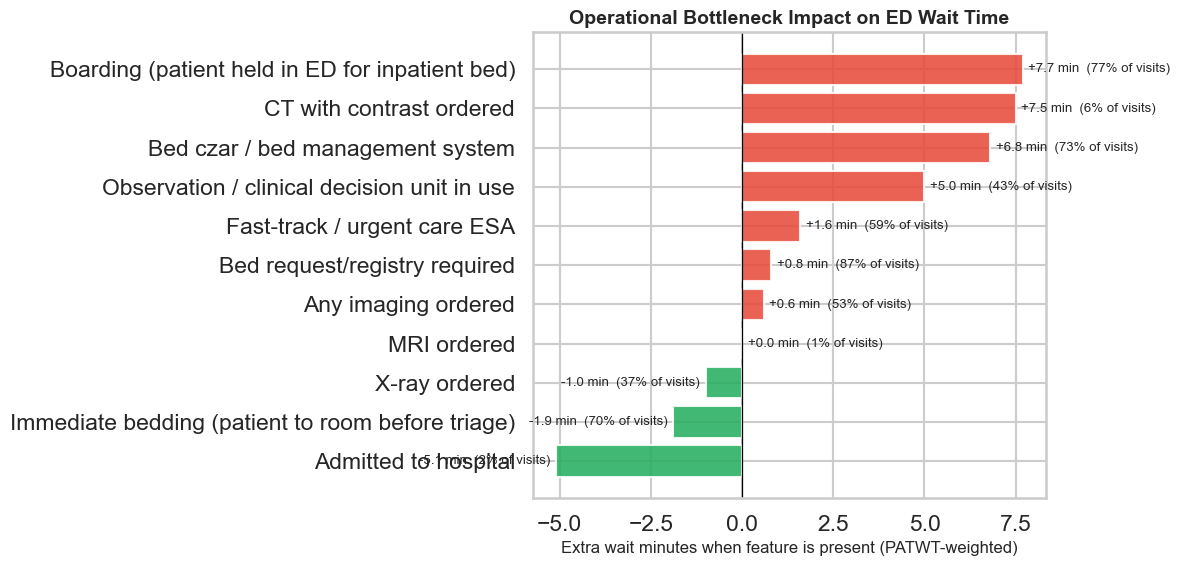

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))

plot_df = group_df.sort_values('Delta_min')
colors = ['#e74c3c' if d > 0 else '#27ae60' for d in plot_df['Delta_min']]
bars = ax.barh(plot_df['Bottleneck Factor'], plot_df['Delta_min'], color=colors, alpha=0.88)
ax.axvline(0, color='black', linewidth=0.9)
ax.set_xlabel('Extra wait minutes when feature is present (PATWT-weighted)', fontsize=12)
ax.set_title('Operational Bottleneck Impact on ED Wait Time', fontsize=14, fontweight='bold')

for bar, (_, row) in zip(bars, plot_df.iterrows()):
    offset = 0.15 if row['Delta_min'] >= 0 else -0.15
    ha = 'left' if row['Delta_min'] >= 0 else 'right'
    ax.text(row['Delta_min'] + offset, bar.get_y() + bar.get_height()/2,
            f"{row['Delta_min']:+.1f} min  ({row['Prevalence_%']:.0f}% of visits)",
            va='center', ha=ha, fontsize=9.5)

plt.tight_layout()
plt.savefig(DATA.parent / 'appengine/assets/bottleneck_delta.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Weighted HGB model + SHAP

A gradient-boosted model trained with PATWT sample weights, then SHAP values decompose each prediction into per-feature contributions. This controls for confounders — e.g., admitted patients both have imaging AND boarding, so SHAP separates their individual effects.

In [4]:
# Feature set: operational flags + arrival context (confounders)
OPERATIONAL = [c for c in [
    'BOARD', 'OBSCLIN', 'FASTTRAK', 'BEDREG', 'IMBED', 'BEDCZAR',
    'ANYIMAGE', 'MRI', 'XRAY', 'CTCONTRAST', 'ADMIT',
    'TOTPROC',
] if c in df.columns]

ARRIVAL_CONTEXT = [c for c in [
    'ARRIVAL_HOUR', 'VDAYR', 'VMONTH', 'IMMEDR', 'AGE', 'PAINSCALE',
    'BPSYS', 'BPDIAS', 'PULSE', 'RESPR', 'TEMPF', 'REGION', 'MSA', 'LOV',
] if c in df.columns]

ALL_FEATURES = OPERATIONAL + ARRIVAL_CONTEXT

# Train on 2015–2018, evaluate on 2022
train = df[df['YEAR'].isin([2015, 2016, 2017, 2018])].copy()
test  = df[df['YEAR'] == 2022].copy()
print(f'Train: {len(train):,}   Test: {len(test):,}')

X_train = train[ALL_FEATURES].copy()
X_test  = test[ALL_FEATURES].copy()
y_train = train['WAITTIME'].values
y_test  = test['WAITTIME'].values

# Normalize PATWT so mean=1 within train set
w_train = train['PATWT'].fillna(train['PATWT'].median()).values
w_train = w_train / w_train.mean()

# Fill NaN: median for numerics, -99 sentinel for categoricals (HGB handles these natively)
cat_cols = ['IMMEDR', 'VDAYR', 'VMONTH', 'REGION', 'MSA',
            'BOARD', 'OBSCLIN', 'FASTTRAK', 'BEDREG', 'IMBED', 'BEDCZAR',
            'ANYIMAGE', 'MRI', 'XRAY', 'CTCONTRAST', 'ADMIT']
cat_cols = [c for c in cat_cols if c in ALL_FEATURES]
num_cols = [c for c in ALL_FEATURES if c not in cat_cols]

train_medians = X_train[num_cols].median()
for frame in [X_train, X_test]:
    frame[num_cols] = frame[num_cols].fillna(train_medians)
    frame[cat_cols] = frame[cat_cols].fillna(-99)

model = HistGradientBoostingRegressor(
    loss='absolute_error',
    learning_rate=0.05,
    max_iter=400,
    max_depth=7,
    min_samples_leaf=40,
    l2_regularization=0.1,
    random_state=42,
)
model.fit(X_train, y_train, sample_weight=w_train)

preds = np.clip(model.predict(X_test), 0, 480)
mae = mean_absolute_error(y_test, preds)
r2  = r2_score(y_test, preds)
print(f'\nTest MAE: {mae:.2f} min   R²: {r2:.4f}')
print('(R² will be low — individual prediction is inherently noisy; we use this model for attribution, not prediction)')

Train: 64,766   Test: 13,216



Test MAE: 28.20 min   R²: -0.0239
(R² will be low — individual prediction is inherently noisy; we use this model for attribution, not prediction)


In [5]:
# SHAP values — use a subsample to keep runtime reasonable
np.random.seed(42)
shap_idx = np.random.choice(len(X_test), size=min(2000, len(X_test)), replace=False)
X_shap = X_test.iloc[shap_idx].reset_index(drop=True)
w_shap = test['PATWT'].iloc[shap_idx].fillna(test['PATWT'].median()).values

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)
shap_df = pd.DataFrame(shap_values, columns=ALL_FEATURES)

# PATWT-weighted mean |SHAP| per feature
w_norm = w_shap / w_shap.sum()
mean_abs_shap = pd.Series(
    {col: np.average(np.abs(shap_df[col]), weights=w_norm) for col in ALL_FEATURES},
    name='mean_abs_shap'
).sort_values(ascending=False)

# Tag which features are operational bottlenecks vs arrival context
is_operational = mean_abs_shap.index.isin(OPERATIONAL)
shap_summary = pd.DataFrame({
    'Feature': mean_abs_shap.index,
    'Mean |SHAP| (min)': mean_abs_shap.values.round(3),
    'Type': ['Operational' if op else 'Context' for op in is_operational]
})
print('Top 20 features by weighted mean |SHAP|:')
display(shap_summary.head(20))

Top 20 features by weighted mean |SHAP|:


,Feature,Mean |SHAP| (min),Type
0,LOV,3.566,Context
1,REGION,1.908,Context
2,ARRIVAL_HOUR,1.772,Context
3,TOTPROC,1.423,Operational
4,FASTTRAK,1.033,Operational
5,VMONTH,1.014,Context
6,OBSCLIN,0.952,Operational
7,IMMEDR,0.872,Context
8,BEDCZAR,0.648,Operational
9,AGE,0.585,Context


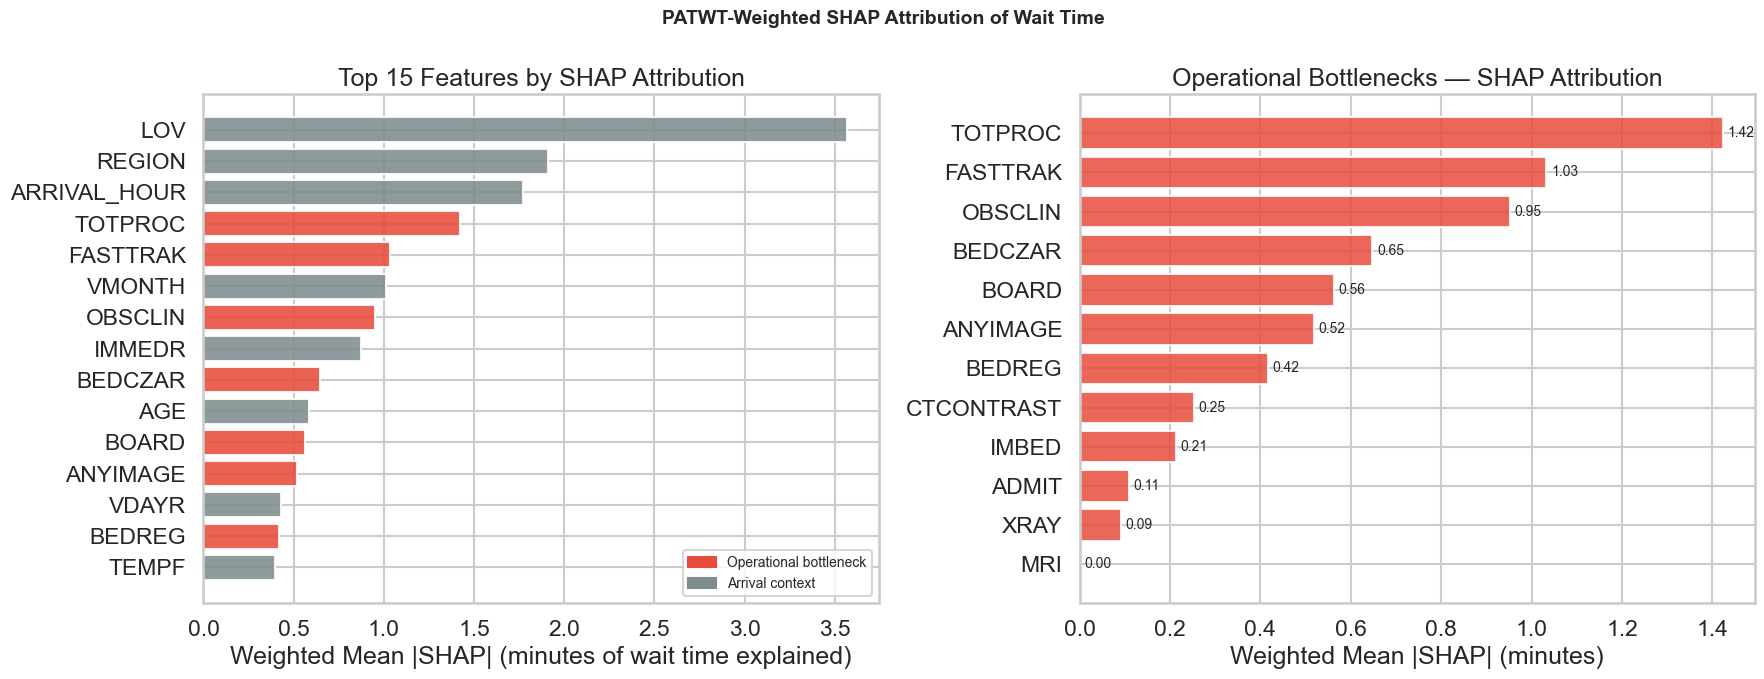

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: top 15 features overall
top15 = shap_summary.head(15)
colors_type = ['#e74c3c' if t == 'Operational' else '#7f8c8d' for t in top15['Type']]
axes[0].barh(top15['Feature'][::-1], top15['Mean |SHAP| (min)'][::-1], color=colors_type[::-1], alpha=0.88)
axes[0].set_xlabel('Weighted Mean |SHAP| (minutes of wait time explained)')
axes[0].set_title('Top 15 Features by SHAP Attribution')

# Add legend
from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color='#e74c3c', label='Operational bottleneck'),
    Patch(color='#7f8c8d', label='Arrival context'),
], fontsize=10)

# Right: operational features only, ranked
ops_shap = shap_summary[shap_summary['Type'] == 'Operational'].sort_values('Mean |SHAP| (min)')
axes[1].barh(ops_shap['Feature'], ops_shap['Mean |SHAP| (min)'], color='#e74c3c', alpha=0.85)
axes[1].set_xlabel('Weighted Mean |SHAP| (minutes)')
axes[1].set_title('Operational Bottlenecks — SHAP Attribution')
for i, (_, row) in enumerate(ops_shap.iterrows()):
    axes[1].text(row['Mean |SHAP| (min)'] + 0.01, i,
                 f"{row['Mean |SHAP| (min)']:.2f}", va='center', fontsize=10)

plt.suptitle('PATWT-Weighted SHAP Attribution of Wait Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA.parent / 'appengine/assets/bottleneck_shap.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Bottleneck ranking

Combine raw delta (group comparison) with SHAP attribution into a single ranked summary.

In [7]:
ops_shap_dict = ops_shap.set_index('Feature')['Mean |SHAP| (min)'].to_dict()

ranking = group_df.copy()
ranking['SHAP_attr_min'] = ranking['Code'].map(ops_shap_dict).round(3)
ranking = ranking.sort_values('SHAP_attr_min', ascending=False, na_position='last')

print('BOTTLENECK RANKING (sorted by SHAP attribution):')
print('=' * 85)
display(
    ranking[['Bottleneck Factor','Prevalence_%','Delta_min','SHAP_attr_min']]
    .rename(columns={
        'Prevalence_%':   'Visits affected (%)',
        'Delta_min':      'Raw delta (min)',
        'SHAP_attr_min':  'SHAP attr (min)',
    })
    .reset_index(drop=True)
)
ranking.to_csv(DATA / 'bottleneck_ranking.csv', index=False)
print('Saved to data/bottleneck_ranking.csv')

BOTTLENECK RANKING (sorted by SHAP attribution):


,Bottleneck Factor,Visits affected (%),Raw delta (min),SHAP attr (min)
0,Fast-track / urgent care ESA,59.2,1.6,1.033
1,Observation / clinical decision unit in use,43.4,5.0,0.952
2,Bed czar / bed management system,73.0,6.8,0.648
3,Boarding (patient held in ED for inpatient bed),77.3,7.7,0.563
4,Any imaging ordered,52.6,0.6,0.519
5,Bed request/registry required,86.7,0.8,0.417
6,CT with contrast ordered,6.3,7.5,0.254
7,Immediate bedding (patient to room before triage),70.0,-1.9,0.214
8,Admitted to hospital,1.7,-5.1,0.109
9,X-ray ordered,36.7,-1.0,0.091


Saved to data/bottleneck_ranking.csv


## 4. Regional breakdown

Which bottlenecks are worst in each region? Hospitals can use this to understand where regional operational patterns deviate from the national picture.

In [8]:
# For the top operational bottlenecks by SHAP, compute the weighted delta by REGION
top_ops = [r['Code'] for _, r in ranking.dropna(subset=['SHAP_attr_min']).head(6).iterrows()]
top_labels = {r['Code']: r['Bottleneck Factor'] for _, r in ranking.iterrows()}

regional_rows = []
for region_code, region_name in REGION_LABELS.items():
    reg = df[df['REGION'] == region_code]
    reg_w = reg['PATWT'].sum()
    reg_overall = wmean(reg['WAITTIME'], reg['PATWT'])
    for col in top_ops:
        if col not in reg.columns:
            continue
        pres_mask, abs_mask = flag_present_absent(reg[col])
        pres_sub = reg[pres_mask]
        abs_sub  = reg[abs_mask]
        if len(pres_sub) < 10 or len(abs_sub) < 10:
            continue
        pres_w = wmean(pres_sub['WAITTIME'], pres_sub['PATWT'])
        abs_w  = wmean(abs_sub['WAITTIME'],  abs_sub['PATWT'])
        regional_rows.append({
            'Region':     region_name,
            'Feature':    top_labels.get(col, col),
            'Code':       col,
            'Delta_min':  round(pres_w - abs_w, 1),
            'Prevalence': round(pres_sub['PATWT'].sum() / reg_w * 100, 1),
            'Region_mean_wait': round(reg_overall, 1),
        })

regional_df = pd.DataFrame(regional_rows)
pivot = regional_df.pivot_table(
    index='Feature', columns='Region', values='Delta_min', aggfunc='first'
).round(1)
print('Wait time delta (present vs absent) by region (minutes):')
display(pivot)
regional_df.to_csv(DATA / 'bottleneck_regional.csv', index=False)

Wait time delta (present vs absent) by region (minutes):


Region,Midwest,Northeast,South,West
Feature,,,,
Any imaging ordered,1.4,1.0,1.1,-1.3
Bed czar / bed management system,12.8,-1.3,8.0,2.9
Bed request/registry required,2.8,-19.0,2.5,-1.2
Boarding (patient held in ED for inpatient bed),8.9,9.2,5.0,11.9
Fast-track / urgent care ESA,2.5,2.0,6.6,-8.5
Observation / clinical decision unit in use,9.3,-2.3,4.0,5.2


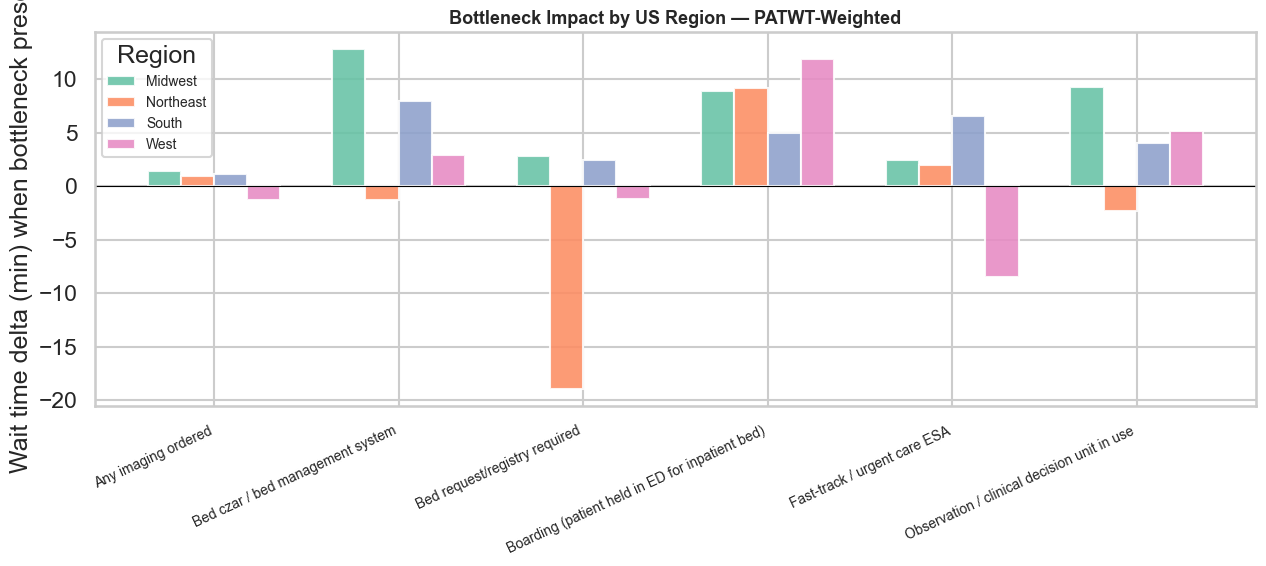

In [9]:
fig, ax = plt.subplots(figsize=(13, 6))

n_features = len(pivot.index)
n_regions  = len(pivot.columns)
x = np.arange(n_features)
width = 0.18
palette = sns.color_palette('Set2', n_regions)

for i, (region, color) in enumerate(zip(pivot.columns, palette)):
    offset = (i - n_regions / 2 + 0.5) * width
    vals = pivot[region].values
    ax.bar(x + offset, vals, width, label=region, color=color, alpha=0.88)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=25, ha='right', fontsize=10)
ax.set_ylabel('Wait time delta (min) when bottleneck present')
ax.set_title('Bottleneck Impact by US Region — PATWT-Weighted', fontsize=13, fontweight='bold')
ax.legend(title='Region', fontsize=10)

plt.tight_layout()
plt.savefig(DATA.parent / 'appengine/assets/bottleneck_by_region.png', dpi=150, bbox_inches='tight')
plt.show()